# Import the necessary libaries

In [1]:
import torch

In [2]:
from sklearn import linear_model, preprocessing

In [3]:
import pandas as pd

In [4]:
import pyampute

In [5]:
from typing import Dict, Any, Union, Set, List, Tuple

In [6]:
from math import floor

In [7]:
from pyampute.exploration.mcar_statistical_tests import MCARTest

In [8]:
from pyampute.ampute import MultivariateAmputation

In [9]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

In [10]:
from ucimlrepo import fetch_ucirepo 

# Inspect the datasets with pre-existing missing values

## Look at <code>HCV data</code> (https://archive.ics.uci.edu/dataset/571/hcv+data)

In [6]:
# fetch dataset 
hcv_data = fetch_ucirepo(id=571) 

In [7]:
hcv_data.metadata

{'uci_id': 571,
 'name': 'HCV data',
 'repository_url': 'https://archive.ics.uci.edu/dataset/571/hcv+data',
 'data_url': 'https://archive.ics.uci.edu/static/public/571/data.csv',
 'abstract': 'The data set contains laboratory values of blood donors and Hepatitis C patients and demographic values like age.',
 'area': 'Health and Medicine',
 'tasks': ['Classification', 'Clustering'],
 'characteristics': ['Multivariate'],
 'num_instances': 615,
 'num_features': 12,
 'feature_types': ['Integer', 'Real'],
 'demographics': ['Age', 'Sex'],
 'target_col': ['Category'],
 'index_col': ['ID'],
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 2020,
 'last_updated': 'Fri Nov 03 2023',
 'dataset_doi': '10.24432/C5D612',
 'creators': ['Ralf Lichtinghagen', 'Frank Klawonn', 'Georg Hoffmann'],
 'intro_paper': {'ID': 237,
  'type': 'NATIVE',
  'title': 'Using machine learning techniques to generate laboratory diagnostic pathways—a case study',
  'authors': 'Geo

In [8]:
type(hcv_data)

ucimlrepo.dotdict.dotdict

In [9]:
print(hcv_data.data.features.head())  # Preview features

   Age Sex   ALB   ALP   AST   BIL    CHE  CHOL   CREA   CGT  PROT   ALT
0   32   m  38.5  52.5  22.1   7.5   6.93  3.23  106.0  12.1  69.0   7.7
1   32   m  38.5  70.3  24.7   3.9  11.17  4.80   74.0  15.6  76.5  18.0
2   32   m  46.9  74.7  52.6   6.1   8.84  5.20   86.0  33.2  79.3  36.2
3   32   m  43.2  52.0  22.6  18.9   7.33  4.74   80.0  33.8  75.7  30.6
4   32   m  39.2  74.1  24.8   9.6   9.15  4.32   76.0  29.9  68.7  32.6


In [10]:
print(hcv_data.data.targets.head())   # Preview targets

        Category
0  0=Blood Donor
1  0=Blood Donor
2  0=Blood Donor
3  0=Blood Donor
4  0=Blood Donor


In [17]:
hcv_data.shape

(615, 12)

### Transform <code>hcv_data</code> from <code>ucimlrepo.dotdict.dotdict</code> into <code>pd.DataFrame</code>

In [12]:
X = hcv_data.data.features 

In [13]:
hcv_data = pd.concat([X], axis=1)

In [14]:
hcv_data.head()

,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
0,32,m,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7
1,32,m,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0
2,32,m,46.9,74.7,52.6,6.1,8.84,5.20,86.0,33.2,79.3,36.2
3,32,m,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6
4,32,m,39.2,74.1,24.8,9.6,9.15,4.32,76.0,29.9,68.7,32.6


In [15]:
hcv_data.tail()

,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
610,62,f,32.0,416.6,110.3,50.0,5.57,6.30,55.7,650.9,68.5,5.9
611,64,f,24.0,102.8,44.4,20.0,1.54,3.02,63.0,35.9,71.3,2.9
612,64,f,29.0,87.3,99.0,48.0,1.66,3.63,66.7,64.2,82.0,3.5
613,46,f,33.0,NaN,62.0,20.0,3.56,4.20,52.0,50.0,71.0,39.0
614,59,f,36.0,NaN,80.0,12.0,9.07,5.30,67.0,34.0,68.0,100.0


In [16]:
hcv_data.describe()

,Age,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
count,615.000000,614.000000,597.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000,614.000000,614.000000
mean,47.408130,41.620195,68.283920,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171,72.044137,28.450814
std,10.055105,5.780629,26.028315,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071,5.402636,25.469689
min,19.000000,14.900000,11.300000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000,0.900000
25%,39.000000,38.800000,52.500000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000,69.300000,16.400000
50%,47.000000,41.950000,66.200000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000,23.000000
75%,54.000000,45.200000,80.100000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000,75.400000,33.075000
max,77.000000,82.200000,416.600000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000,325.300000


#### Count the number of rows without missing values

In [58]:
num_complete_instances = hcv_data.notna().all(axis=1).sum()

In [59]:
num_complete_instances

589

#### Examine the number of complete cases versus total cases

In [60]:
round(num_complete_instances/hcv_data.shape[0], 4)

0.9577

#### Explore the metadata patterns

In [61]:
from pyampute.exploration.md_patterns import mdPatterns

In [62]:
mdPatternGenerator = mdPatterns()

/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/md_patterns.py:120: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  group_values = group_values.append(colsums, ignore_index=True)


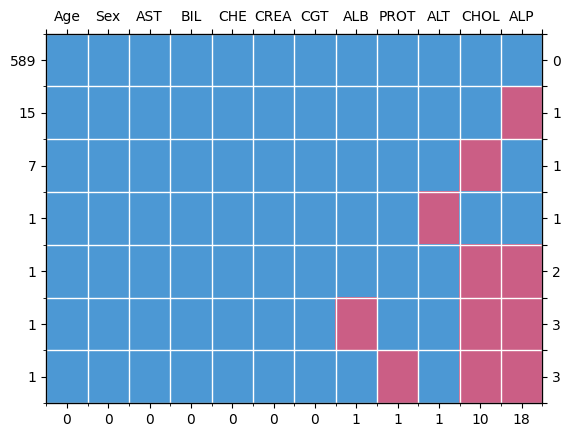

In [63]:
hcv_data_patterns = mdPatternGenerator.get_patterns(hcv_data)

#### Filter out the patients with missing values so that we would have complete baseline values

In [42]:
hcv_data[hcv_data.notna().all(axis=1)].reset_index(drop=True)

,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
0,32,m,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7
1,32,m,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0
2,32,m,46.9,74.7,52.6,6.1,8.84,5.20,86.0,33.2,79.3,36.2
3,32,m,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6
4,32,m,39.2,74.1,24.8,9.6,9.15,4.32,76.0,29.9,68.7,32.6
...,...,...,...,...,...,...,...,...,...,...,...,...
584,58,f,34.0,46.4,150.0,8.0,6.26,3.98,56.0,49.7,80.6,15.0
585,59,f,39.0,51.3,285.8,40.0,5.77,4.51,136.1,101.1,70.5,19.6
586,62,f,32.0,416.6,110.3,50.0,5.57,6.30,55.7,650.9,68.5,5.9
587,64,f,24.0,102.8,44.4,20.0,1.54,3.02,63.0,35.9,71.3,2.9


In [169]:
hcv_data_no_missing = hcv_data[hcv_data.notna().all(axis=1)].reset_index(drop=True).copy()

In [170]:
hcv_data_no_missing.shape

(589, 12)

### Imputing the dataset with missing values and demographic features (age, sex)

In [71]:
hcv_data.shape

(615, 12)

#### Perform a Little's MCAR statistical test on this dataset 

In [89]:
mcar_tester = MCARTest(method="little")

In [91]:
print(mcar_tester.little_mcar_test(hcv_data))

/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/mcar_statistical_tests.py:85: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  gmean = dataset.mean()
/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/mcar_statistical_tests.py:86: FutureWarning: The default value of numeric_only in DataFrame.cov is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  gcov = dataset.cov()
/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/mcar_statistical_tests.py:104: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future

KeyError: "['Sex'] not in index"

#### Practice one-hot encoding for the attribute "Sex" then

In [195]:
hcv_data_cp = hcv_data.copy()

In [213]:
hcv_data_cp.dtypes

Age       int64
Sex      object
ALB     float64
ALP     float64
AST     float64
BIL     float64
CHE     float64
CHOL    float64
CREA    float64
CGT     float64
PROT    float64
ALT     float64
dtype: object

In [197]:
# create a 0/1 “is_male” column
hcv_data['is_male']   = (hcv_data_cp['Sex'] == 'm').astype(int)

# create a 0/1 “is_female” column
hcv_data['is_female'] = (hcv_data_cp['Sex'] == 'f').astype(int)

In [199]:
hcv_data.drop(["Sex"], axis=1, inplace=True)

In [200]:
hcv_data.dtypes

Age            int64
ALB          float64
ALP          float64
AST          float64
BIL          float64
CHE          float64
CHOL         float64
CREA         float64
CGT          float64
PROT         float64
ALT          float64
is_male        int64
is_female      int64
dtype: object

Perform Little's MCAR test again

In [201]:
print(mcar_tester.little_mcar_test(hcv_data))

0.0


The dataset does not fulfill the requirement of "MCAR"

Again, check the missingness rate of every feature again

In [262]:
complete_attributes: List[str] = []

In [263]:
for col in hcv_data.columns:
    missing_prop = hcv_data[col].isna().sum() / hcv_data.shape[0]
    if not missing_prop > 0:
        complete_attributes.append(col)
    print(f"Missingness of the attribute {col}: {round(missing_prop, 2)}")

Missingness of the attribute Age: 0.0
Missingness of the attribute ALB: 0.0
Missingness of the attribute ALP: 0.03
Missingness of the attribute AST: 0.0
Missingness of the attribute BIL: 0.0
Missingness of the attribute CHE: 0.0
Missingness of the attribute CHOL: 0.02
Missingness of the attribute CREA: 0.0
Missingness of the attribute CGT: 0.0
Missingness of the attribute PROT: 0.0
Missingness of the attribute ALT: 0.0
Missingness of the attribute is_male: 0.0
Missingness of the attribute is_female: 0.0


In [264]:
complete_attributes

['Age', 'AST', 'BIL', 'CHE', 'CREA', 'CGT', 'is_male', 'is_female']

In [209]:
hcv_data.shape

(615, 13)

<b>Conclusion</b>: The missingness rate is extremely small for the two features with missing values. Therefore, we can assign a mask matrix in numpy, then simply impute the missing values via BRR following amputation

Adding an "original" missingness mask

In [210]:
# Boolean mask: True where the entry is missing
missing_mask = hcv_data.isna().to_numpy()
# shape == (n_rows, n_cols), dtype=bool

# If you need 0/1 instead of True/False:
missing_mask = missing_mask.astype(int)

In [212]:
missing_mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]])

<b> <code>1</code> represents the originally unobserved values, We would like to assign originally observed but artificially amputed values later into <code>2</code> in this mask </b>

#### Practice amputation on the originally observed values then

In [217]:
missing_rate = [0.05*rate for rate in range(1, 6)]

In [218]:
missing_rates

(0.05, 0.1, 0.15000000000000002, 0.2, 0.25)

perform amputation using the following reference: https://rianneschouten.github.io/pyampute/build/html/auto_examples/plot_simulation_pipeline.html

##### Create the missing patterns of MAR in the following loop

In [219]:
len(hcv_data.columns)

13

In [220]:
hcv_data.columns

Index(['Age', 'ALB', 'ALP', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'CGT', 'PROT',
       'ALT', 'is_male', 'is_female'],
      dtype='object')

Leave <code>Age</code> as the complete vars, otherwise amputation cannot be done

In [234]:
MAR_pattern = \
[{
    "incomplete_vars": [k for k in range(1, len(hcv_data.columns))],
    "complete_vars": [0],
    "mechanism": "MAR"

}]

In [246]:
amputed_hcv_dfs: List[Tuple[float, pd.DataFrame]] = []

In [247]:
for missing_rate in missing_rates:
    amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
    amputed_hcv_df = amputor.fit_transform(hcv_data)
    amputed_hcv_dfs.append((missing_rate, amputed_hcv_df))

2025-05-20 11:07:29,241 [WARNING] Failed to load lookup table for a prespecified score to probability function. It is possible data/shift_lookup.csv is missing, in the wrong location, or corrupted. Try rerunning scripts/generate_shift_lookup_table.py to regenerate the lookup table.
2025-05-20 11:07:29,257 [WARNING] Candidates for pattern 0 all have almost the same weighted sum scores. It is possible this is due to the use of binary variables in amputation. This creates problems when using the sigmoid function for the score_to_probability_func. Currently our solution is as follows: if there is just one candidate with a sum score 0, we will ampute it. If there is one candidate with a nonzero sum score, or multiple candidates with the same score, we evenly apply as if MCAR.
2025-05-20 11:07:29,261 [WARNING] Failed to load lookup table for a prespecified score to probability function. It is possible data/shift_lookup.csv is missing, in the wrong location, or corrupted. Try rerunning script

In [269]:
amputed_hcv_df

,Age,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT,is_male,is_female
0,32,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7,1.0,0.0
1,32,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0,1.0,0.0
2,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,32,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6,1.0,0.0
4,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
611,64,24.0,102.8,44.4,20.0,1.54,3.02,63.0,35.9,71.3,2.9,0.0,1.0
612,64,29.0,87.3,99.0,48.0,1.66,3.63,66.7,64.2,82.0,3.5,0.0,1.0
613,46,33.0,NaN,62.0,20.0,3.56,4.20,52.0,50.0,71.0,39.0,0.0,1.0


<b>Conclusion:</b> unfortunately, we could see that all the features in the same patient gets amputed, this is not what we desired. Therefore, we would have to ampute feature by feature, then replace the processed originally dataset feature by feature 

In [252]:
hcv_data_preprocessed = hcv_data.copy()

In [271]:
amputed_hcv_dfs: List[Tuple[float, pd.DataFrame]] = []

In [273]:
for missing_rate in missing_rates:
    hcv_data_temp = hcv_data_preprocessed.copy()
    for col in hcv_data_preprocessed.columns:
        MAR_pattern = \
        [{
            "incomplete_vars": [col],
            "mechanism": "MAR"

        }]
        amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
        amputed_hcv_df = amputor.fit_transform(hcv_data_preprocessed)
        hcv_data_temp.loc[:, col] = amputed_hcv_df[col].values
    amputed_hcv_dfs.append((missing_rate, hcv_data_temp))

2025-05-20 11:23:35,313 [WARNING] Failed to load lookup table for a prespecified score to probability function. It is possible data/shift_lookup.csv is missing, in the wrong location, or corrupted. Try rerunning scripts/generate_shift_lookup_table.py to regenerate the lookup table.


AssertionError: Features involved in amputation must be complete, but contains NaNs.

Unfortunately, we would have to perform pre-imputation using the Bayesian Ridge Regressor:

In [278]:
# 1) my preprocessed DataFrame with NaNs
df_temp = hcv_data_preprocessed.copy()

# 2) set up the imputer to use BayesianRidge
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,          # number of imputation rounds
    tol=1e-3,             # convergence tolerance
    random_state=0,
)

# 3) fit & transform
imputed_array = imputer.fit_transform(df_temp)

# 4) rewrap into a DataFrame
hcv_data_preprocessed_imputed = pd.DataFrame(imputed_array, columns=df_temp.columns, index=df_temp.index)

In [297]:
# validating the imputation
hcv_data_preprocessed_imputed.notna().all(axis=1).sum() == hcv_data_preprocessed.shape[0]

True

In [ ]:
for missing_rate in missing_rates:
    hcv_data_temp = hcv_data_preprocessed_imputed.copy()
    for col in hcv_data_preprocessed_imputed.columns:
        MAR_pattern = \
        [{
            "incomplete_vars": [col],
            "mechanism": "MAR"
        }]
        amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
        amputed_hcv_df = amputor.fit_transform(hcv_data_preprocessed_imputed)
        hcv_data_temp.loc[:, col] = amputed_hcv_df[col].values
    amputed_hcv_dfs.append((missing_rate, hcv_data_temp))

In [286]:
df_temp = None

In [290]:
amputed_hcv_dfs[-1]

(0.25,
       Age   ALB         ALP   AST   BIL    CHE  CHOL   CREA   CGT  PROT  \
 0    32.0  38.5   52.500000  22.1   7.5   6.93   NaN  106.0  12.1  69.0   
 1    32.0  38.5   70.300000   NaN   3.9  11.17  4.80   74.0  15.6  76.5   
 2     NaN  46.9         NaN   NaN   6.1   8.84  5.20   86.0  33.2  79.3   
 3     NaN  43.2   52.000000  22.6   NaN   7.33  4.74   80.0   NaN  75.7   
 4    32.0  39.2   74.100000   NaN   9.6   9.15   NaN   76.0  29.9  68.7   
 ..    ...   ...         ...   ...   ...    ...   ...    ...   ...   ...   
 610   NaN   NaN         NaN   NaN   NaN    NaN   NaN    NaN   NaN   NaN   
 611  64.0  24.0  102.800000  44.4  20.0   1.54  3.02   63.0  35.9  71.3   
 612  64.0   NaN   87.300000  99.0  48.0   1.66  3.63   66.7  64.2  82.0   
 613   NaN  33.0   69.125598  62.0  20.0   3.56  4.20   52.0  50.0   NaN   
 614  59.0   NaN   77.428426   NaN   NaN   9.07  5.30   67.0  34.0  68.0   
 
        ALT  is_male  is_female  
 0      7.7      1.0        0.0  
 1     18.0

In [291]:
amputed_hcv_dfs_MAR = amputed_hcv_dfs

In [293]:
amputed_hcv_dfs_MAR[-1][-1].tail()

,Age,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT,is_male,is_female
610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
611,64.0,24.0,102.800000,44.4,20.0,1.54,3.02,63.0,35.9,71.3,NaN,0.0,1.0
612,64.0,NaN,87.300000,99.0,48.0,1.66,3.63,66.7,64.2,82.0,3.5,0.0,1.0
613,NaN,33.0,69.125598,62.0,20.0,3.56,4.20,52.0,50.0,NaN,39.0,0.0,1.0
614,59.0,NaN,77.428426,NaN,NaN,9.07,5.30,67.0,34.0,68.0,100.0,NaN,1.0


So we obtained what we desired here!

##### Create the missing patterns of MNAR in the following loop

In [298]:
amputed_hcv_dfs = []

In [ ]:
for missing_rate in missing_rates:
    hcv_data_temp = hcv_data_preprocessed_imputed.copy()
    for col in hcv_data_preprocessed_imputed.columns:
        MAR_pattern = \
        [{
            "incomplete_vars": [col],
            "mechanism": "MNAR"
        }]
        amputor = MultivariateAmputation(prop=missing_rate, patterns=MAR_pattern)
        amputed_hcv_df = amputor.fit_transform(hcv_data_preprocessed_imputed)
        hcv_data_temp.loc[:, col] = amputed_hcv_df[col].values
    amputed_hcv_dfs.append((missing_rate, hcv_data_temp))

In [300]:
amputed_hcv_dfs_MNAR = amputed_hcv_dfs

In [302]:
amputed_hcv_dfs_MNAR[-1]

(0.25,
       Age   ALB         ALP   AST   BIL   CHE  CHOL   CREA   CGT  PROT   ALT  \
 0    32.0   NaN   52.500000  22.1   7.5  6.93  3.23  106.0  12.1  69.0   NaN   
 1    32.0  38.5         NaN  24.7   3.9   NaN  4.80   74.0  15.6   NaN  18.0   
 2    32.0   NaN         NaN  52.6   6.1  8.84  5.20    NaN  33.2  79.3   NaN   
 3    32.0  43.2   52.000000  22.6  18.9  7.33  4.74   80.0   NaN  75.7  30.6   
 4    32.0  39.2   74.100000  24.8   9.6   NaN  4.32   76.0  29.9   NaN  32.6   
 ..    ...   ...         ...   ...   ...   ...   ...    ...   ...   ...   ...   
 610   NaN  32.0         NaN   NaN  50.0   NaN  6.30   55.7   NaN  68.5   5.9   
 611   NaN  24.0  102.800000  44.4  20.0  1.54  3.02   63.0  35.9  71.3   2.9   
 612   NaN  29.0   87.300000   NaN  48.0  1.66  3.63   66.7   NaN   NaN   3.5   
 613  46.0  33.0   69.125598   NaN  20.0  3.56  4.20   52.0  50.0  71.0  39.0   
 614  59.0  36.0   77.428426   NaN  12.0  9.07  5.30   67.0  34.0  68.0   NaN   
 
      is_male  is_f

In [73]:
amputed_hcv_dfs_MNAR[-1][-1].tail()

,Age,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT,is_male,is_female
610,62.0,32.0,NaN,NaN,50.0,5.57,6.30,55.7,NaN,68.5,5.9,0.0,1.0
611,NaN,24.0,NaN,NaN,NaN,1.54,3.02,63.0,35.9,71.3,NaN,NaN,1.0
612,NaN,29.0,NaN,99.0,NaN,1.66,3.63,66.7,64.2,NaN,3.5,0.0,1.0
613,NaN,33.0,69.125598,NaN,20.0,3.56,4.20,52.0,50.0,71.0,NaN,NaN,1.0
614,NaN,36.0,NaN,NaN,12.0,NaN,NaN,NaN,NaN,68.0,NaN,0.0,NaN


We obtained what we want as well!

##### Export the amputed MNAR and MAR dataframes

##### Create the missing patterns of MAR in the following loop

In [74]:
%%bash
mkdir -p amputed_datasets && mkdir -p amputed_datasets/HCV_data

In [75]:
for missing_rate, amputed_df in amputed_hcv_dfs_MAR:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/HCV_data/hcv_data_amputed_MAR_{int(missing_rate*100)}_perc.csv', index=False)

In [76]:
for missing_rate, amputed_df in amputed_hcv_dfs_MNAR:
    # export to a file
    amputed_df.to_csv(f'amputed_datasets/HCV_data/hcv_data_amputed_MNAR_{int(missing_rate*100)}_perc.csv', index=False)

## Look at <code>Regensburg Appendicitis Dataset</code> (https://archive.ics.uci.edu/dataset/938/regensburg+pediatric+appendicitis)

In [18]:
# fetch dataset 
rgsbg_appendicitis_dataset = fetch_ucirepo(id=938) 
  
# data (as pandas dataframes) 
X = rgsbg_appendicitis_dataset.data.features 
y = rgsbg_appendicitis_dataset.data.targets 

In [33]:
rgsbg_appendicitis_df = pd.concat([X], axis=1)

In [34]:
rgsbg_appendicitis_df.shape

(782, 53)

In [35]:
rgsbg_appendicitis_df.describe()

,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP
count,781.000000,755.000000,756.000000,779.000000,778.000000,730.000000,730.000000,498.000000,775.000000,776.000000,679.000000,54.000000,764.000000,764.000000,756.000000,764.000000,771.000000
mean,11.346451,18.907012,148.017460,43.172542,4.284062,5.921918,5.253425,7.762651,37.404516,12.670683,71.791163,64.929630,4.799490,13.380497,13.180291,285.252618,31.386900
std,3.529909,4.385331,19.732016,17.390984,2.574057,2.155972,1.958456,2.536671,0.903678,5.366525,14.463656,15.085025,0.499012,1.393271,4.538774,72.494373,57.433854
min,0.000000,7.830000,53.000000,3.960000,1.000000,0.000000,0.000000,2.700000,26.900000,2.600000,27.200000,32.000000,3.620000,8.200000,11.200000,91.000000,0.000000
25%,9.200000,15.725000,137.000000,29.500000,3.000000,4.000000,4.000000,6.000000,36.800000,8.200000,61.400000,54.500000,4.537500,12.600000,12.300000,236.000000,1.000000
50%,11.440000,18.060000,149.650000,41.400000,3.000000,6.000000,5.000000,7.500000,37.200000,12.000000,75.500000,64.500000,4.780000,13.300000,12.700000,276.000000,7.000000
75%,14.100000,21.180000,163.000000,54.000000,5.000000,8.000000,7.000000,9.100000,37.900000,16.200000,83.600000,77.500000,5.020000,14.000000,13.300000,330.000000,33.000000
max,18.360000,38.160000,192.000000,103.000000,28.000000,10.000000,10.000000,17.000000,40.200000,37.700000,97.700000,91.000000,14.000000,36.000000,86.900000,708.000000,365.000000


Discover more about the metadata patterns of <code>rgsbg_appendicitis_df</code>

In [36]:
from pyampute.exploration.md_patterns import mdPatterns

In [37]:
mdPatternGenerator = mdPatterns()

/Users/jiz/miniconda3/envs/imputation_env/lib/python3.10/site-packages/pyampute/exploration/md_patterns.py:120: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  group_values = group_values.append(colsums, ignore_index=True)


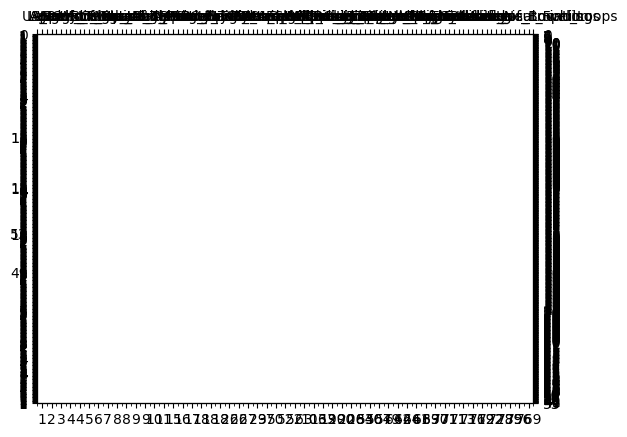

In [39]:
rgsbg_appendicitis_patterns = mdPatternGenerator.get_patterns(rgsbg_appendicitis_df)

It's unfortunately impossible to visualize the missingness pattern in this dataset since there's too much missingness

Instead, we would like to use a dictionary to record the missing rate per feature

In [44]:
rgsbg_appendicitis_df.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay',
       'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US',
       'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia',
       'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count',
       'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria',
       'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'US_Performed', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign',
       'Appendicolith', 'Perfusion', 'Perforation',
       'Surrounding_Tissue_Reaction', 'Appendicular_Abscess',
       'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location',
       'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus',
       'Coprostasis', 'Me

In [53]:
rgsbg_dataset_col_missingness_dict: Dict[str, float] = {}

In [52]:
for col in list(rgsbg_appendicitis_df.columns):
    

SyntaxError: incomplete input (787382552.py, line 2)